<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


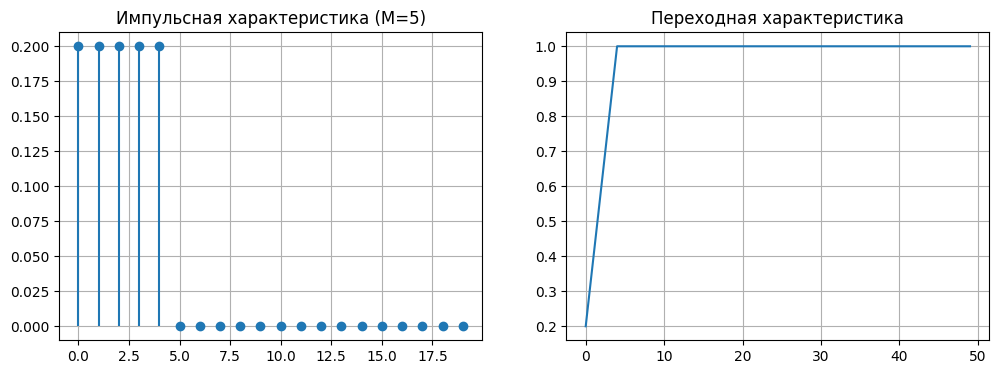

In [2]:
M = 5
b = np.ones(M) / M
a = [1]

impulse = np.zeros(20)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

step = np.ones(50)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:**
Импульсная характеристика ограничена во времени, так как отклик на единичный импульс совпадает с коэффициентами фильтра, число которых конечно. Переходная характеристика выходит на постоянный уровень, поскольку сумма коэффициентов фильтра скользящего среднего нормирована к единице. При подаче константы на вход фильтра выходной сигнал стабилизируется на том же уровне.




### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


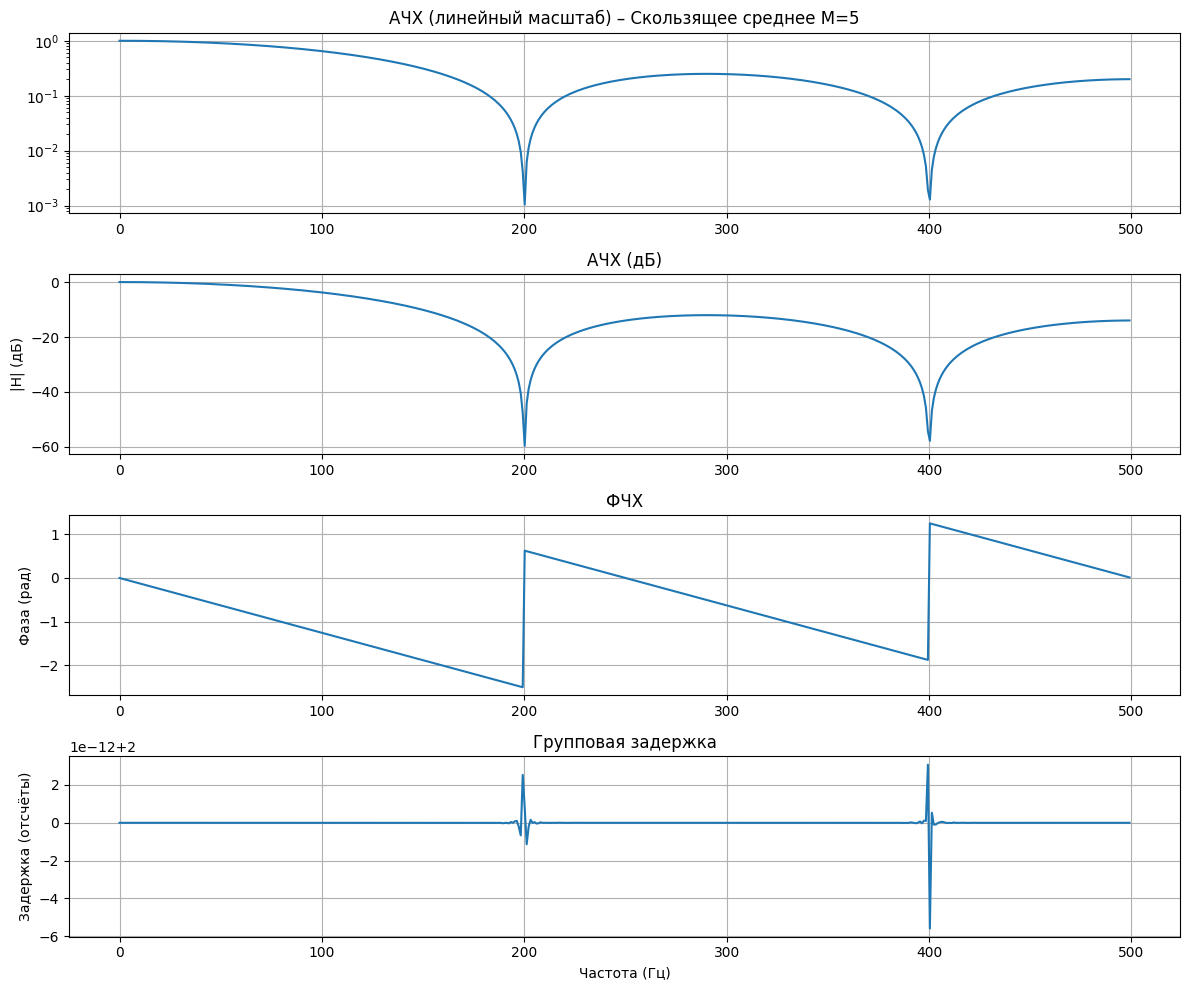

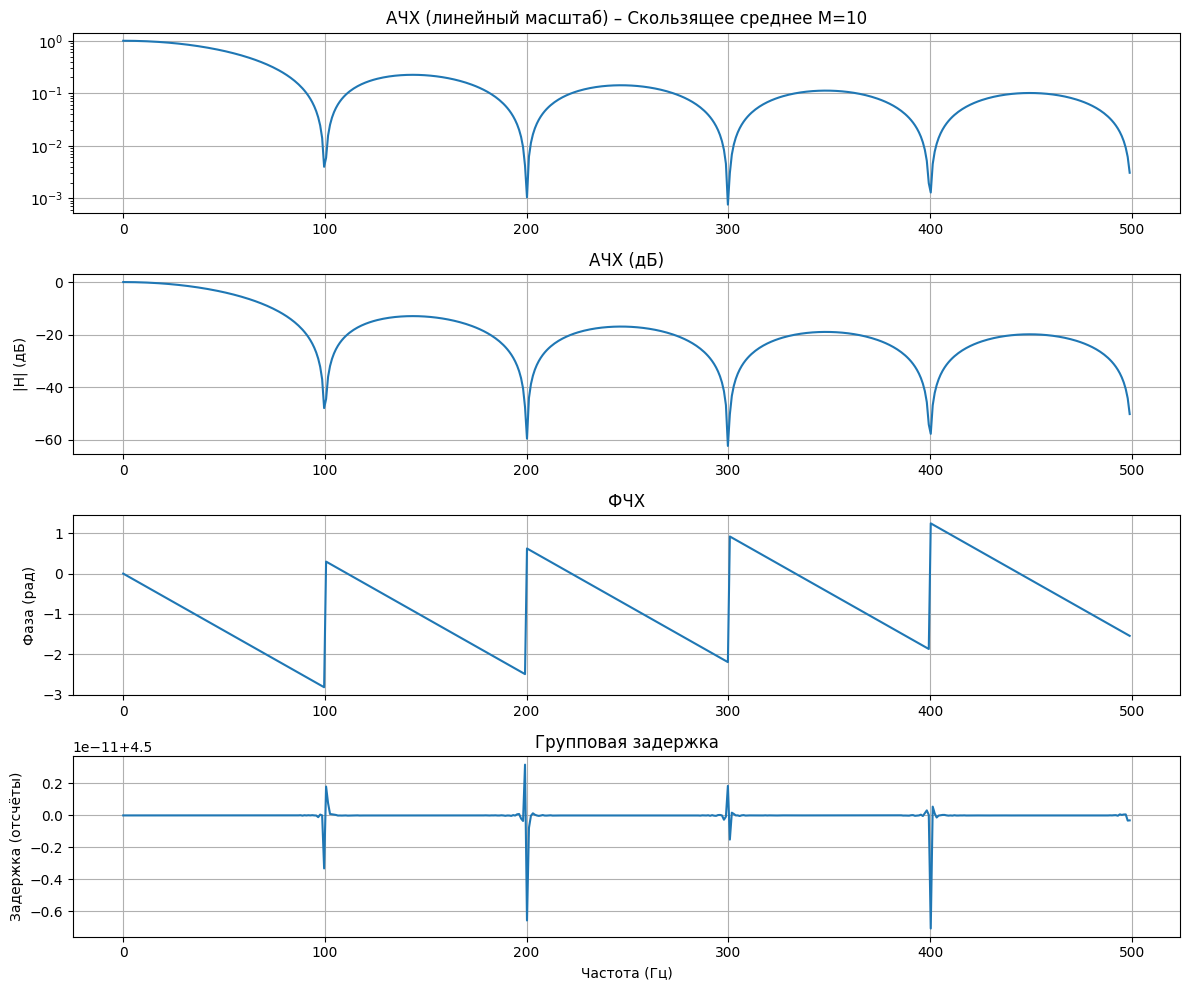

/tmp/ipykernel_9014/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


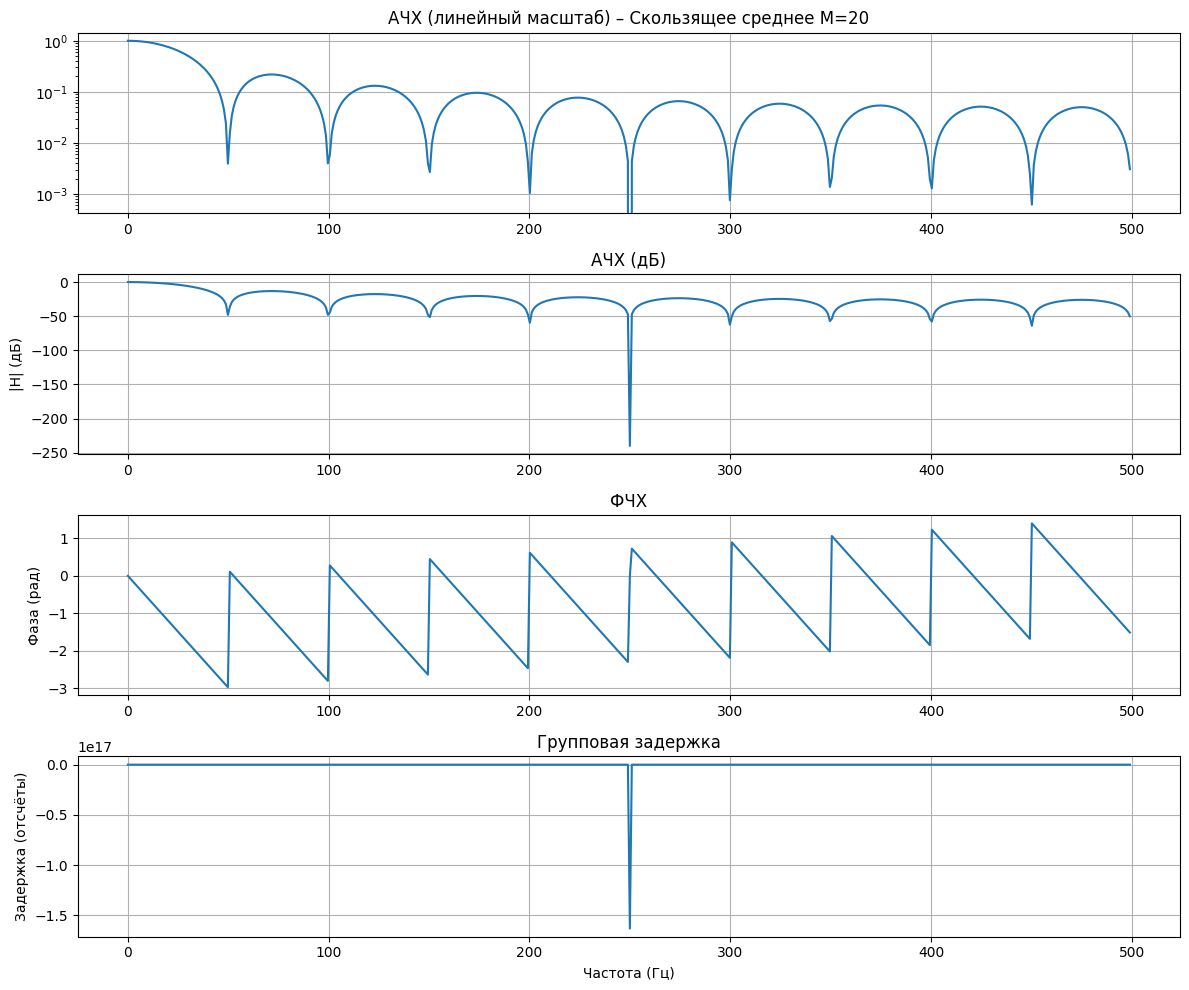

In [4]:
# Для M=5
b5 = np.ones(5)/5
plot_filter_response(b5, [1], fs=1000, title='Скользящее среднее M=5')

# Для M=10
b10 = np.ones(10)/10
plot_filter_response(b10, [1], fs=1000, title='Скользящее среднее M=10')

# Для M=20
b20 = np.ones(20)/20
plot_filter_response(b20, [1], fs=1000, title='Скользящее среднее M=20')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**
При увеличении M фильтр сильнее подавляет высокие частоты, а переходная область АЧХ становится уже.
C ФЧХ аналогично.


### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


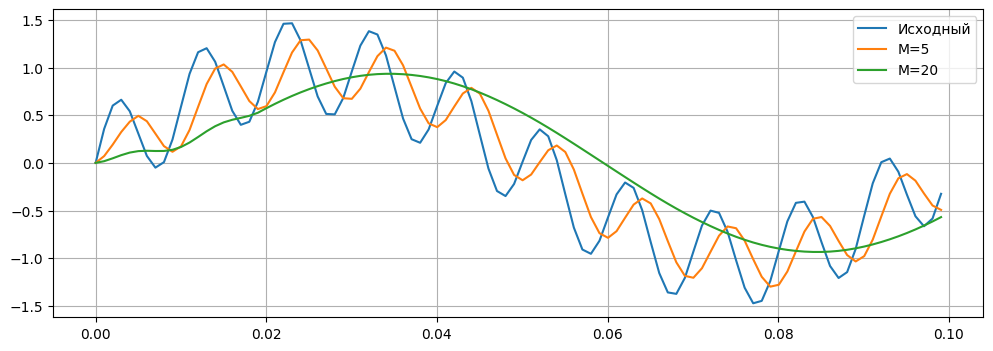

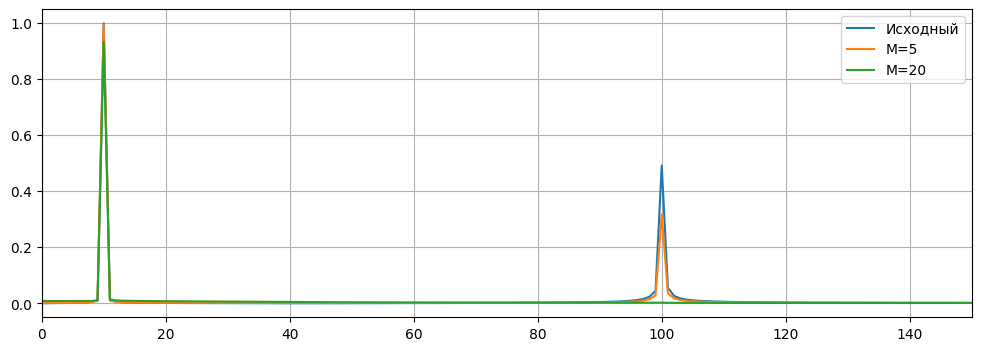

In [5]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

y5 = signal.lfilter(np.ones(5)/5, [1], x)
y20 = signal.lfilter(np.ones(20)/20, [1], x)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], y5[:100], label='M=5')
plt.plot(t[:100], y20[:100], label='M=20')
plt.legend()
plt.grid()
plt.show()

def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:**

 При увеличении М амплитуда 100 Гц сигнала уменьшается сильнее, чем 10 Гц. Это связано с тем, что спектральный компонент 100 Гц оказывается в зоне подавления АЧХ. Амплитуда спектральных составляющих сигнала после фильтрации прямо пропорциональна коэффициенту передачи фильтра на соответствующих частотах.


## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


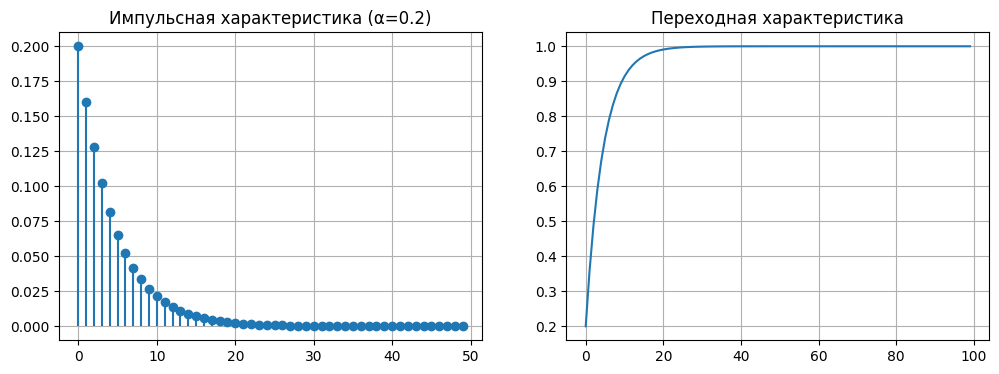

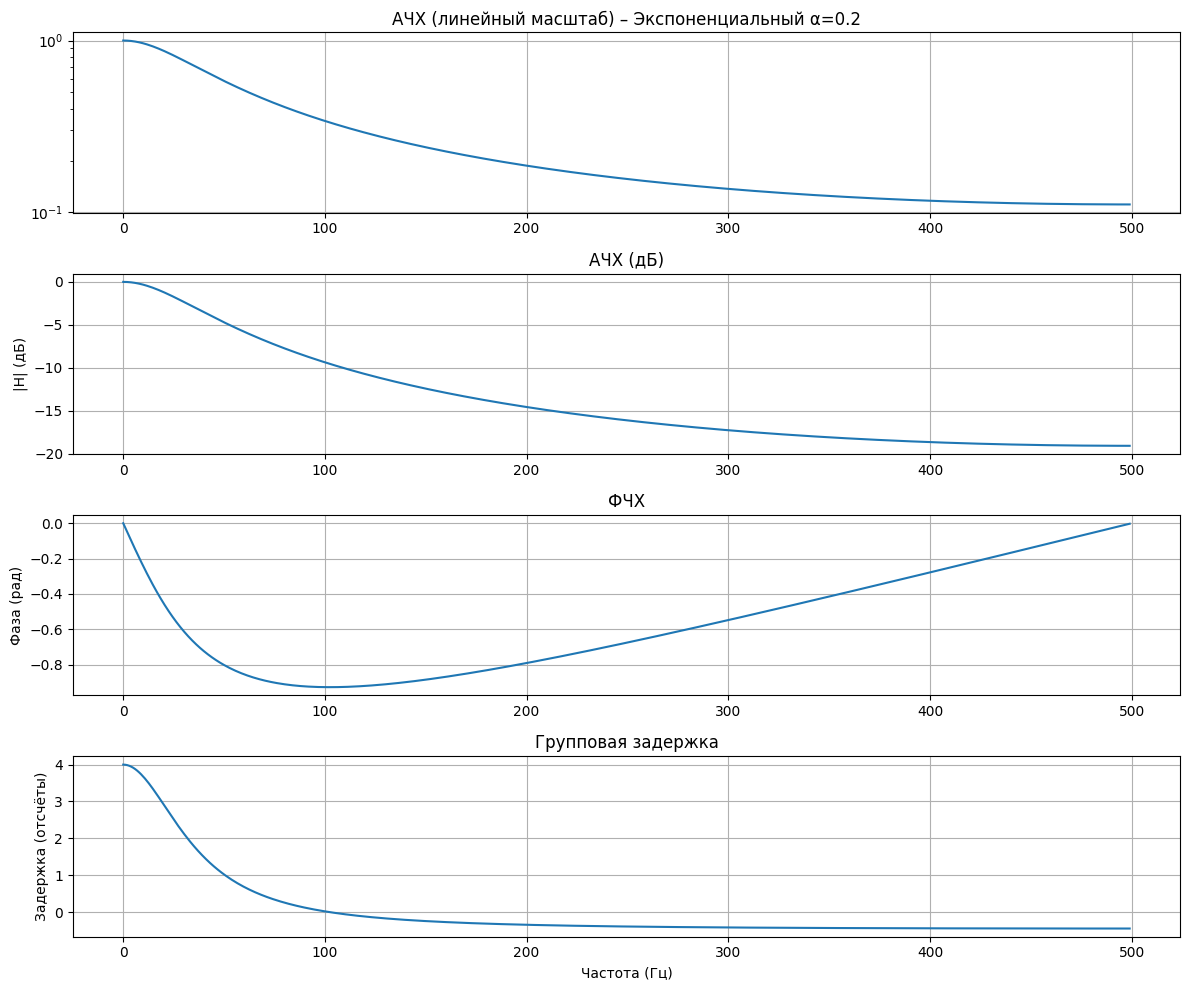

In [6]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


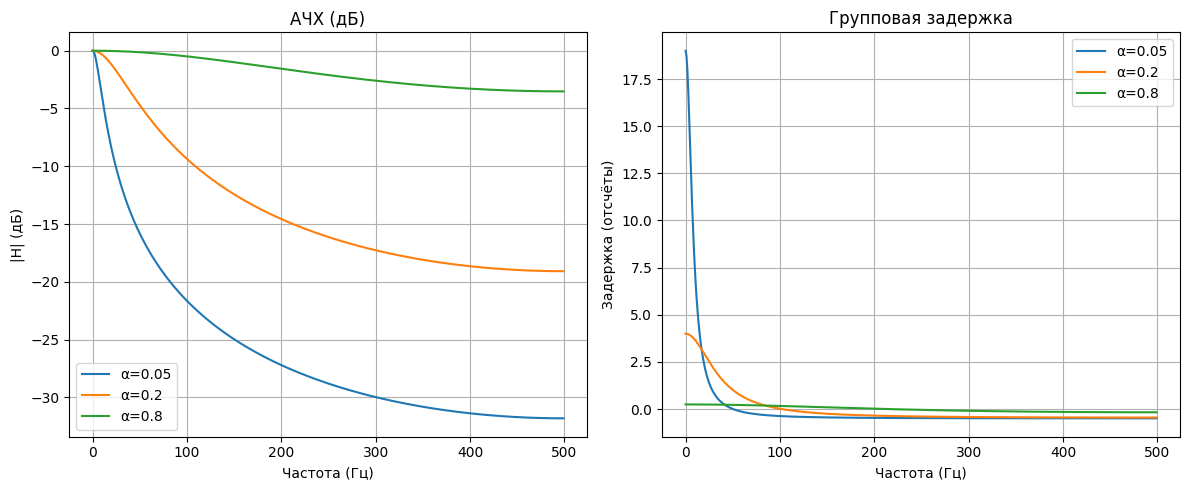

In [7]:
alphas = [0.05, 0.2, 0.8]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for alpha in alphas:
    b, a = [alpha], [1, -(1 - alpha)]
    w, H = signal.freqz(b, a, fs=1000)
    plt.plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=f'α={alpha}')
plt.title('АЧХ (дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
for alpha in alphas:
    b, a = [alpha], [1, -(1 - alpha)]
    w_gd, gd = signal.group_delay((b, a), fs=1000)
    plt.plot(w_gd, gd, label=f'α={alpha}')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:**
Чем меньше альфа, тем более круче график, но возрастает групповая задержка.

### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


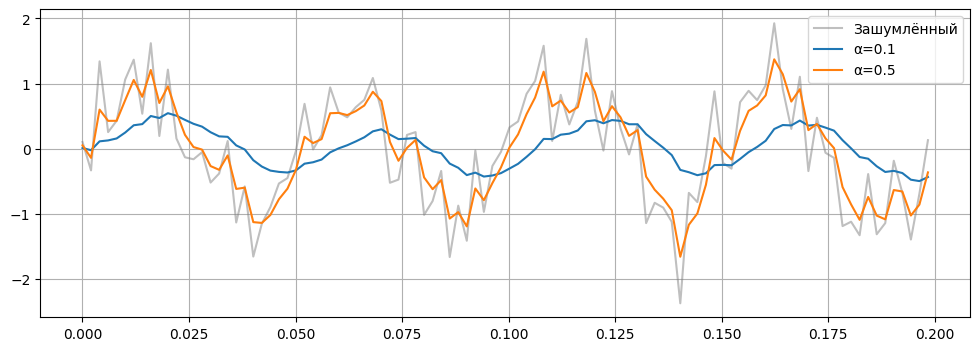

In [8]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

y_alpha_01 = signal.lfilter([0.1], [1, -0.9], x_noisy)
y_alpha_05 = signal.lfilter([0.5], [1, -0.5], x_noisy)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], y_alpha_01[:100], label='α=0.1')
plt.plot(t[:100], y_alpha_05[:100], label='α=0.5')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:**
Групповая задержка влияет на сдвиг и время задержки. При уменьшении альфа сдвиг и время задержки становится больше.

## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


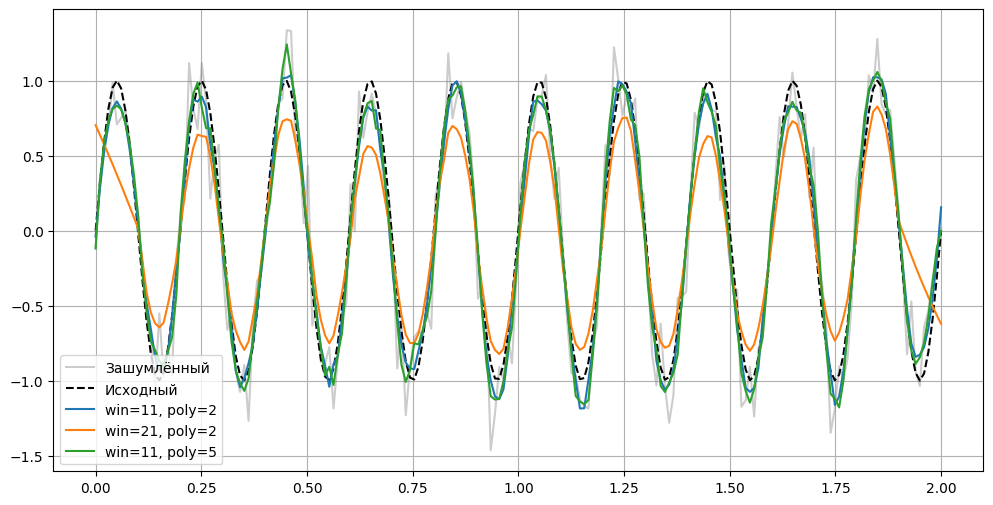

In [9]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', label='Исходный')
plt.plot(t, y1, label='win=11, poly=2')
plt.plot(t, y2, label='win=21, poly=2')
plt.plot(t, y3, label='win=11, poly=5')
plt.legend()
plt.grid()
plt.show()

**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:**
Увеличение window_length усиливает сглаживание и лучше подавляет шум, но приводит к искажению сигнала. Увеличение polyorder позволяет фильтру лучше сохранять пики, однако эффективность подавления шума при этом падает.

### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


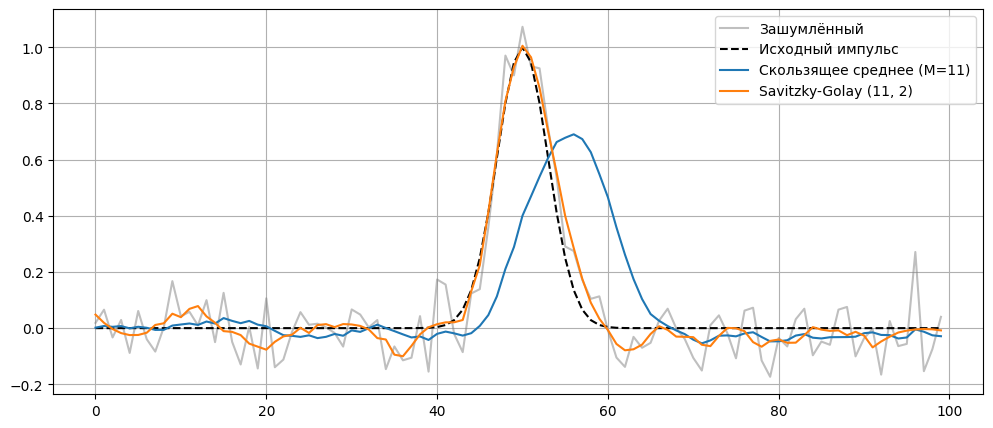

In [10]:
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

y_ma = signal.lfilter(np.ones(11)/11, [1], x_noisy_pulse)
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')
plt.plot(y_ma, label='Скользящее среднее (M=11)')
plt.plot(y_sg, label='Savitzky-Golay (11, 2)')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:**
Savitzky–Golay лучше сохраняет пик.


### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


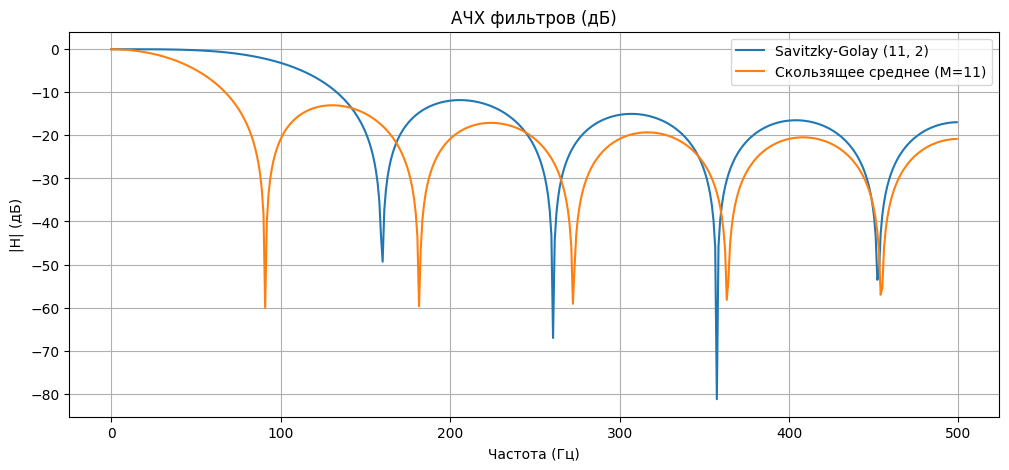

In [11]:
window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)

b_ma = np.ones(11) / 11

w_sg, H_sg = signal.freqz(coeffs, [1], fs=1000)
w_ma, H_ma = signal.freqz(b_ma, [1], fs=1000)

plt.figure(figsize=(12, 5))
plt.plot(w_sg, 20 * np.log10(np.abs(H_sg) + 1e-12), label='Savitzky-Golay (11, 2)')
plt.plot(w_ma, 20 * np.log10(np.abs(H_ma) + 1e-12), label='Скользящее среднее (M=11)')
plt.title('АЧХ фильтров (дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


**Ответ:**
АЧХ Savitzky–Golay медленнее увеличивает крутизну, чем скользящее среднее, которое сильнее подавляет высокие частоты и вносит заметное сглаживание на средних и высоких частотах.

### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


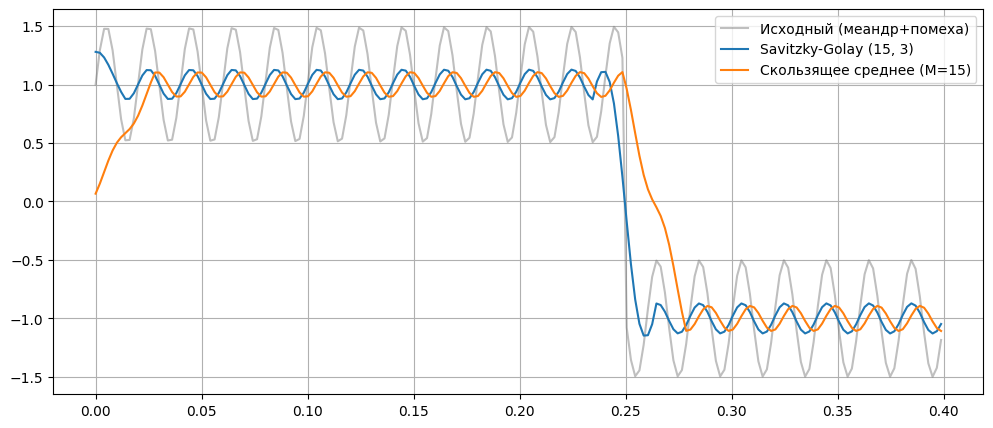

In [12]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

y_sg = savgol_filter(x_meander, window_length=15, polyorder=3)
y_ma = signal.lfilter(np.ones(15)/15, [1], x_meander)

plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], 'gray', alpha=0.5, label='Исходный (меандр+помеха)')
plt.plot(t[:200], y_sg[:200], label='Savitzky-Golay (15, 3)')
plt.plot(t[:200], y_ma[:200], label='Скользящее среднее (M=15)')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:**
 Savitzky–Golay лучше подходит, так как он не даёт смещения.

## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


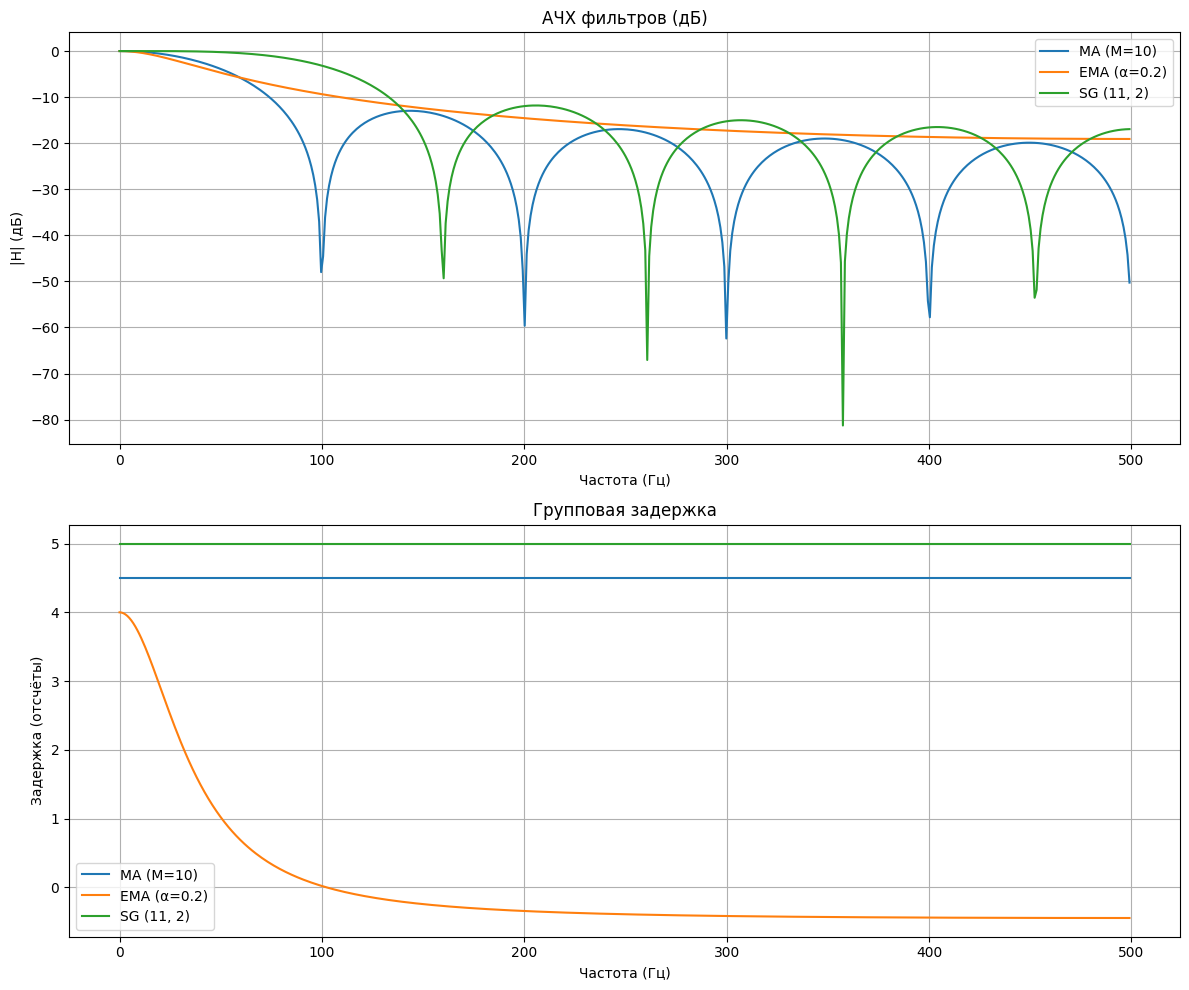

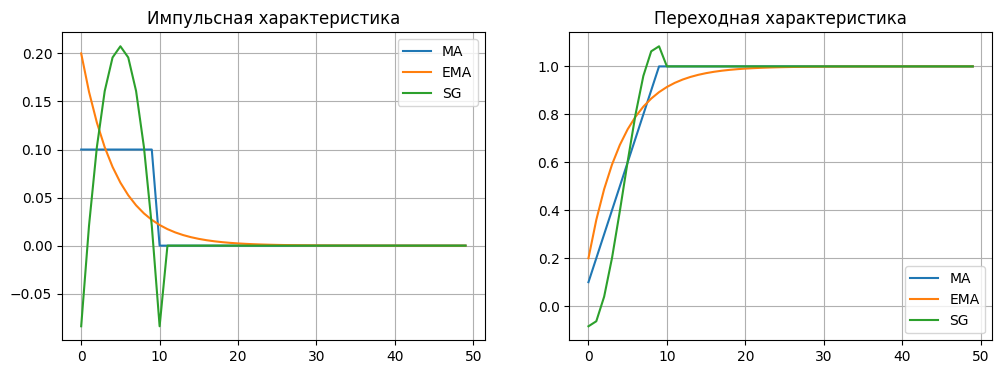

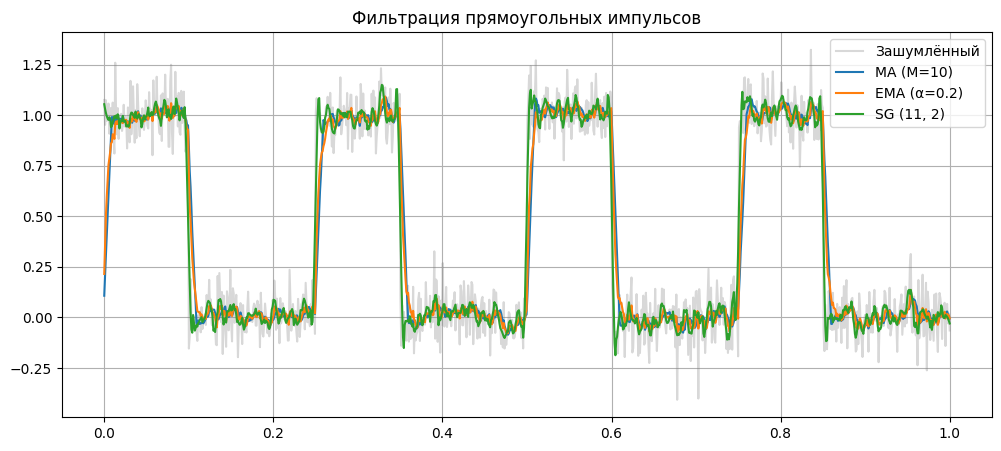

In [13]:
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

b_ma, a_ma = np.ones(10)/10, [1]
b_ema, a_ema = [0.2], [1, -0.8]
b_sg = savgol_coeffs(11, 2)
b_sg = b_sg / np.sum(b_sg)
a_sg = [1]

w_ma, H_ma = signal.freqz(b_ma, a_ma, fs=fs)
w_ema, H_ema = signal.freqz(b_ema, a_ema, fs=fs)
w_sg, H_sg = signal.freqz(b_sg, a_sg, fs=fs)

wgd_ma, gd_ma = signal.group_delay((b_ma, a_ma), fs=fs)
wgd_ema, gd_ema = signal.group_delay((b_ema, a_ema), fs=fs)
wgd_sg, gd_sg = signal.group_delay((b_sg, a_sg), fs=fs)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(w_ma, 20*np.log10(np.abs(H_ma)+1e-12), label='MA (M=10)')
plt.plot(w_ema, 20*np.log10(np.abs(H_ema)+1e-12), label='EMA (α=0.2)')
plt.plot(w_sg, 20*np.log10(np.abs(H_sg)+1e-12), label='SG (11, 2)')
plt.title('АЧХ фильтров (дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(wgd_ma, gd_ma, label='MA (M=10)')
plt.plot(wgd_ema, gd_ema, label='EMA (α=0.2)')
plt.plot(wgd_sg, gd_sg, label='SG (11, 2)')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

impulse = np.zeros(50)
impulse[0] = 1
step = np.ones(50)

h_ma = signal.lfilter(b_ma, a_ma, impulse)
h_ema = signal.lfilter(b_ema, a_ema, impulse)
h_sg = signal.lfilter(b_sg, a_sg, impulse)

s_ma = signal.lfilter(b_ma, a_ma, step)
s_ema = signal.lfilter(b_ema, a_ema, step)
s_sg = signal.lfilter(b_sg, a_sg, step)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_ma, label='MA')
plt.plot(h_ema, label='EMA')
plt.plot(h_sg, label='SG')
plt.title('Импульсная характеристика')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(s_ma, label='MA')
plt.plot(s_ema, label='EMA')
plt.plot(s_sg, label='SG')
plt.title('Переходная характеристика')
plt.legend()
plt.grid()
plt.show()

y_ma = signal.lfilter(b_ma, a_ma, x_pulse_noisy)
y_ema = signal.lfilter(b_ema, a_ema, x_pulse_noisy)
y_sg = savgol_filter(x_pulse_noisy, window_length=11, polyorder=2)

plt.figure(figsize=(12, 5))
plt.plot(t, x_pulse_noisy, 'gray', alpha=0.3, label='Зашумлённый')
plt.plot(t, y_ma, label='MA (M=10)')
plt.plot(t, y_ema, label='EMA (α=0.2)')
plt.plot(t, y_sg, label='SG (11, 2)')
plt.title('Фильтрация прямоугольных импульсов')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:**

Лучшее подавление - скользящее среднее.

Сохранение фронтов -  Savitzky–Golay.

Наименьшие фазовые искажения -  Savitzky–Golay.